# HSC Preparation

> Data preparation for a [worked example](05_hsc_analysis.ipynb) of analysing the ICL in images from the HSC-SSP deep survey.

In [ ]:
# | default_exp hsc.preparation

In [ ]:
# | export
from os.path import join

import astropy.cosmology.units as cu
import astropy.units as u
from astropy.nddata import CCDData
from astropy.table import QTable
from importlib.resources import files

from nicl.utilities import physical_to_angular

In [ ]:
# | hide
# Additional imports used in this notebook
import gzip
from getpass import getpass
from glob import glob
from itertools import product
from os.path import exists

import matplotlib.pyplot as plt
import numpy as np
from astropy.cosmology import FlatLambdaCDM
from astropy.table import unique
from astropy.visualization import AsinhStretch, ImageNormalize

from nicl.hsc_utils import hscReleaseQuery as hrq
from nicl.hsc_utils.downloadCutout import Rect, download

Setting the path at which to store local data:

In [ ]:
local_data_path = "/Users/spb/data/hsc/"

## Cluster catalogue

We will use the cluster catalogue of [Furnell et al. (2021)](https://ui.adsabs.harvard.edu/abs/2021MNRAS.502.2419F/abstract), hereafter F21. Tables have been taken from the LaTeX paper source and manually edited for more direct reading. The catalogue of clusters is in table 2 of F21.

In [ ]:
# | exports


def get_f21_table2_original():
    """Get the XSC cluster properties from Furnell et al. (2021) as a QTable."""
    fn = files("nicl.data.hsc").joinpath("furnell21_table2.tex")
    tab = QTable.read(
        fn,
        format="ascii.latex",
        units=[None, u.deg, u.deg, cu.redshift, u.ABmag]
        + [u.keV] * 3
        + [u.Mpc] * 3
        + [10**14 * u.Msun] * 3,
    )
    return tab


def get_f21_table2():
    """Get the XSC cluster properties from Furnell et al. (2021) as a QTable.

    Include some additional calculated columns for convenience.
    """
    tab = get_f21_table2_original()
    tab["R_X_arcsec"] = physical_to_angular(tab["R_X"], tab["z"]).to(u.arcsec)
    return tab

In [ ]:
f21_clusters = get_f21_table2()
f21_clusters[:3]

XCS ID,ra,dec,z,M_i,T_X,T_X-err,T_X+err,R_X,R_X-err,R_X+err,M_X,M_X+err,M_X-err,R_X_arcsec
,deg,deg,redshift,mag(AB),keV,keV,keV,Mpc,Mpc,Mpc,1e+14 solMass,1e+14 solMass,1e+14 solMass,arcsec
str25,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
XMMXCS J022456.1-050802.0,36.234,-5.134,0.084,-23.023,0.648,0.034,0.034,0.331,0.01,0.01,0.112,0.01,0.01,209.7511921841702
XMMXCS J161039.2+540604.0,242.664,54.101,0.339,-23.718,1.595,0.227,0.373,0.483,0.062,0.041,0.457,0.105,0.198,99.84147736239238
XMMXCS J233137.8+000735.0,352.908,0.126,0.224,-23.69,1.719,0.184,0.269,0.537,0.046,0.033,0.553,0.971,0.156,149.10718587215214


## Images

To download the images we make use of the [image cutout tool provided by HSC](https://hsc-gitlab.mtk.nao.ac.jp/ssp-software/data-access-tools/-/tree/master/pdr3/downloadCutout/).

In [ ]:
def fetch_cluster_cutout(name, ra, dec, radius, filter, hsc_user, hsc_password):
    """Fetch a HSC-SSP image of a cluster and save to disk.

    Parameters
    ----------
    name : str
        Filename in which to save the downloaded image.
    ra : float
        RA coordinate of the cluster centre, in degrees.
    dec : float
        Dec coordinate of the cluster centre, in degrees.
    radius : float
        The half-size of the cutout image, in degrees.
    filter : str
        The filter to fetch, e.g. "i".
    hsc_user : str
        The user of the HSC website account used to access the data.
    hsc_password : str
        The password of the HSC website account used to access the data.

    """
    rect = Rect.create(
        rerun="pdr3_dud_rev",
        type="coadd/bg",
        filter=filter,
        ra=ra,
        dec=dec,
        sw=radius,
        sh=radius,
        image=True,
        mask=True,
        variance=True,
        name=name,
    )
    download(rect, user=hsc_user, password=hsc_password, onmemory=False)

In [ ]:
# | exports


def make_xcs_filename(xcs_id, filter, data_path):
    """Construct the filename (without extension) for a given `xcs_id` and `filter`."""
    xcs_id = xcs_id.replace(" ", "_")
    return join(data_path, f"{xcs_id}/{xcs_id}_{filter}")

In [ ]:
def fetch_f21_cluster_cutout(
    xcs_id, filter, hsc_user, hsc_password, data_path, overwrite=False
):
    """Fetch a HSC-SSP image of an F21 cluster and save to disk.

    Parameters
    ----------
    xcs_id : floats
        XCS ID of the cluster.
    filter : string
        The filter to fetch, e.g. "i".
    hsc_user, hsc_password : strings
        The user and password of the HSC website account used to access the data.
    data_path : string
        The folder in which to store the downloaded images.
    overwrite : bool, default False
        Force overwriting of existing files.

    """
    f21_clusters = get_f21_table2()
    cluster = f21_clusters[f21_clusters["XCS ID"] == xcs_id][0]
    name = make_xcs_filename(xcs_id, filter, data_path)
    if overwrite or not exists(f"{name}.fits"):
        ra = cluster["ra"].to_value("deg")
        dec = cluster["dec"].to_value("deg")
        z = cluster["z"]
        cosmo = FlatLambdaCDM(H0=70, Om0=0.3)
        deg_per_Mpc = 1 / cosmo.kpc_proper_per_arcmin(z).to(u.Mpc / u.deg)
        radius = (1.5 * cluster["R_X"] * deg_per_Mpc).to_value("deg")
        fetch_cluster_cutout(name, ra, dec, radius, filter, hsc_user, hsc_password)


def fetch_all_f21_cluster_cutouts(hsc_user, hsc_password, data_path, overwrite=False):
    """Save HSC-SSP grizy images of all F21 clusters to disk.

    Parameters
    ----------
    hsc_user, hsc_password : strings
        The user and password of the HSC website account used to access the data.
    data_path : string
        The folder in which to store the downloaded images.
    overwrite : bool, default False
        Force overwriting of existing files.

    """
    f21_clusters = get_f21_table2()
    for xcs_id in f21_clusters["XCS ID"]:
        print(xcs_id, end=": ")
        for filter in "grizy":
            print(filter, end="")
            fetch_f21_cluster_cutout(
                xcs_id, filter, hsc_user, hsc_password, data_path, overwrite
            )
        print()

One can run `fetch_all_f21_cluster_cutouts` to get all the required images.

In [ ]:
# |hide
user = password = ""

In [ ]:
# |eval: false
user = getpass("HSC user? ")
password = getpass("HSC password? ")

HSC user?  ········
HSC password?  ········


In [ ]:
fetch_all_f21_cluster_cutouts(user, password, local_data_path)

XMMXCS J022456.1-050802.0: grizy
XMMXCS J161039.2+540604.0: grizy
XMMXCS J233137.8+000735.0: grizy
XMMXCS J232923.6-004854.7: grizy
XMMXCS J161134.1+541640.5: grizy
XMMXCS J095902.7+025544.9: grizy
XMMXCS J095901.2+024740.4: grizy
XMMXCS J100141.6+022538.8: grizy
XMMXCS J095737.1+023428.9: grizy
XMMXCS J022156.8-054521.9: grizy
XMMXCS J022148.1-034608.0: grizy
XMMXCS J022530.8-041421.1: grizy
XMMXCS J100047.3+013927.8: grizy
XMMXCS J022726.5-043207.1: grizy
XMMXCS J022524.8-044043.4: grizy
XMMXCS J095951.2+014045.8: grizy
XMMXCS J022401.9-050528.4: grizy
XMMXCS J095924.7+014614.1: grizy


Now let's take a look at one of the downloaded images.

In [ ]:
# | exports


def f21_cluster_image(xcs_id, filter, data_path, return_hdus=False):
    fn = make_xcs_filename(xcs_id, filter, data_path) + ".fits"
    print(fn)
    img = CCDData.read(fn, unit="adu", hdu=1)
    mask = CCDData.read(fn, unit=u.dimensionless_unscaled, hdu=2)
    sigma = CCDData.read(fn, unit="adu", hdu=3)
    return img, mask, sigma

In [ ]:
xcs_id = f21_clusters[0]["XCS ID"]
img, mask, sigma = f21_cluster_image(xcs_id, "i", local_data_path)

/Users/spb/data/hsc/XMMXCS_J022456.1-050802.0/XMMXCS_J022456.1-050802.0_i.fits


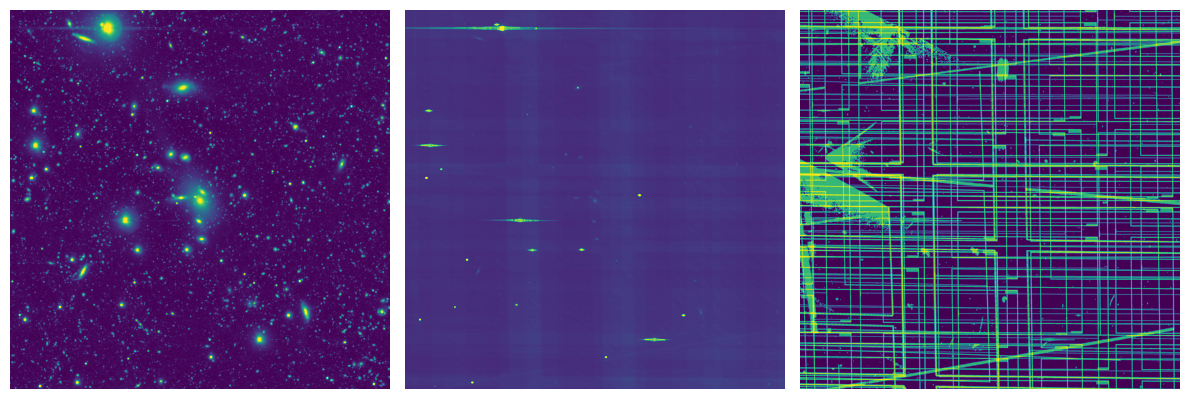

In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(12, 5))
ax[0].imshow(img, norm=ImageNormalize(vmin=-0.01, vmax=10, stretch=AsinhStretch(0.01)))
ax[1].imshow(sigma, norm=ImageNormalize(vmin=0, vmax=0.1, stretch=AsinhStretch(0.01)))
ax[2].imshow(mask)
for a in ax:
    a.axis("off")
plt.tight_layout()

## Galaxy catalogues

These are downloaded from the HSC [CAS](https://hsc-release.mtk.nao.ac.jp/datasearch/catalog_jobs), using the [provided tool](https://hsc-gitlab.mtk.nao.ac.jp/ssp-software/data-access-tools/-/tree/master/pdr3/hscReleaseQuery).

The field limits are defined in terms of RA and Dec ranges:

In [ ]:
# | exports
fields = dict(
    XMMLSS=[33.5, 38, -6.5, -3] * u.deg,
    COSMOS=[148, 152, 0.5, 4] * u.deg,
    ELAISN1=[240, 246, 53, 57] * u.deg,
    DEEP23=[350, 354.5, -2, 1.5] * u.deg,
)


def find_field(coord):
    for f, bounds in fields.items():
        ra_low, ra_high, dec_low, dec_high = bounds
        if (
            (ra_low < coord.ra)
            and (coord.ra < ra_high)
            and (dec_low < coord.dec)
            and (coord.dec < dec_high)
        ):
            return f

In [ ]:
def hsc_query(credential, sql, outfn, format="csv"):
    """Perform an SQL query on the HSC CAS database."""
    job = hrq.submitJob(credential, sql, out_format=format)
    hrq.blockUntilJobFinishes(credential, job["id"])
    with open(outfn, "wb") as outfile:
        hrq.download(credential, job["id"], outfile)
    hrq.deleteJob(credential, job["id"])

In [ ]:
def fetch_galaxy_catalogue(
    field, bounds, hsc_user, hsc_password, data_path, overwrite=False
):
    """Download the galaxy catalogue for the specified `field`."""
    credential = {"account_name": hsc_user, "password": hsc_password}
    field_cat_sql = """
    SELECT f.object_id, ra, dec,
    g_kronflux_mag, g_kronflux_magerr, r_kronflux_mag, r_kronflux_magerr, i_kronflux_mag, i_kronflux_magerr,
    z_kronflux_mag, z_kronflux_magerr, y_kronflux_mag, y_kronflux_magerr,
    i_kronflux_radius,
    photoz_best, photoz_risk_best, photoz_std_best, specz_redshift, specz_redshift_err,
    i_mask_brightstar_halo
    FROM pdr3_dud.forced as f
    LEFT JOIN pdr3_dud.forced2 USING (object_id)
    LEFT JOIN pdr3_dud.photoz_demp USING (object_id)
    LEFT JOIN pdr3_dud.masks USING (object_id)
    LEFT JOIN pdr3_dud.specz USING (object_id)	
    WHERE isprimary
    AND boxSearch(coord, {}, {}, {}, {});
    """
    outfn = join(data_path, f"{field}_cat.fits")
    if overwrite or not exists(outfn):
        sql = field_cat_sql.format(*bounds.to_value("deg"))
        hsc_query(credential, sql, outfn, format="fits")

Now download the catalogue for each field:

In [ ]:
for field in fields:
    fetch_galaxy_catalogue(field, fields[field], user, password, local_data_path)

## Bright Object Masks

The masks are [provided in the data release](https://hsc-release.mtk.nao.ac.jp/archive/filetree/pdr3_dud_rev/deepCoadd/BrightObjectMasks/) as one region file for each "patch", of which there are 81 in a "tract". We download these, then parse them to create a table of the mask regions within each field.

We first need to identify the "tracts" covering each field.

In [ ]:
def fetch_tracts(field, bounds, hsc_user, hsc_password, data_path, overwrite=False):
    """Download the galaxy catalogue for the specified `field`."""
    credential = {"account_name": hsc_user, "password": hsc_password}
    tract_sql = """
    SELECT DISTINCT tract
    FROM pdr3_dud_rev.mosaic
    WHERE mosaic.areacube && cube_from_radecrange({}, {}, {}, {});
    """
    outfn = join(data_path, f"{field}_tracts.csv")
    if overwrite or not exists(outfn):
        sql = tract_sql.format(*bounds)
        hsc_query(credential, sql, outfn)

Now download the tracts for each field:

In [ ]:
for field in fields:
    fetch_tracts(field, fields[field], user, password, local_data_path)

To download the region files efficiently, use `wget`:

```shell
cd $local_data_path
mkdir masks
cd masks
cat ../*tracts.csv | grep -v "#" | tr -d '\r' | xargs -I TRACT wget --user $user --password $password -r -nc -np -nd -A "*[GRIZY].reg" https://hsc-release.mtk.nao.ac.jp/archive/filetree/pdr3_dud_rev/deepCoadd/BrightObjectMasks/TRACT/
```

Then gzip all the `.reg` files to save disk space.

We parse the regions files ourselves as this is much faster than using the regions AstroPy-affiliated package.

In [ ]:
def parse_region_params(s):
    return [
        x.strip().replace("d", "") for x in s[s.find("(") + 1 : s.find(")")].split(",")
    ]

In [ ]:
def parse_region_line(s, nodip=True):
    if s.startswith("circle"):
        ra, dec, radius = parse_region_params(s)
        if nodip and radius == "0.011111":
            return None
        else:
            return "circle", ra, dec, radius, radius
    elif s.startswith("box"):
        ra, dec, width, height, _ = parse_region_params(s)
        return "box", ra, dec, width, height

In [ ]:
def read_regions_file(fn):
    with gzip.open(fn, "rt") as f:
        data = [parse_region_line(s) for s in f]
    regions = [d for d in data if d is not None]
    return regions

In [ ]:
def get_regions(tract, i, j, band, data_path):
    fn = join(
        data_path,
        "masks",
        f"BrightObjectMask-{tract}-{i},{j}-HSC-{band}.reg.gz",
    )
    return read_regions_file(fn)

In [ ]:
def process_mask(tracts_fn, filter, data_path, overwrite=False):
    field = tracts_fn[tracts_fn.rfind("/") + 1 : tracts_fn.find("_")]
    outfn = join(data_path, f"{field}_{filter}_brightmaskdata.fits")
    if overwrite or not exists(outfn):
        tracts = QTable.read(
            tracts_fn, format="ascii.commented_header", header_start=-1
        )["tract"]
        regions = []
        patches = list(product(tracts, range(9), range(9)))
        for tract, i, j in patches:
            reg = get_regions(tract, i, j, filter, data_path)
            regions.extend(reg)
        shape, ra, dec, width, height = np.transpose(regions)
        mask_table = QTable(
            dict(
                ra=ra.astype(float) * u.deg,
                dec=dec.astype(float) * u.deg,
                shape=shape,
                width=width.astype(float) * u.deg,
                height=height.astype(float) * u.deg,
            )
        )
        mask_table = unique(mask_table)
        mask_table.write(outfn, overwrite=True)

In [ ]:
for f in sorted(glob(join(local_data_path, "*tracts.csv"))):
    print(f, end=": ")
    for filter in "grizy":
        print(filter, end="")
        process_mask(f, filter, local_data_path)
    print()

/Users/spb/data/hsc/COSMOS_tracts.csv: grizy
/Users/spb/data/hsc/DEEP23_tracts.csv: grizy
/Users/spb/data/hsc/ELAISN1_tracts.csv: grizy
/Users/spb/data/hsc/XMMLSS_tracts.csv: grizy


This produces tables containing the masked regions within each field.

In [ ]:
# | hide
import nbdev

nbdev.nbdev_export()